In [ ]:
# invesrigate how the probability changes when the lenght of needles is compared to spacing.

#https://www.paulkepley.com/2021-05-13-AsymptoticBuffon/


# Idea of box plot link:

#https://www.paulkepley.com/2021-05-13-AsymptoticBuffon/

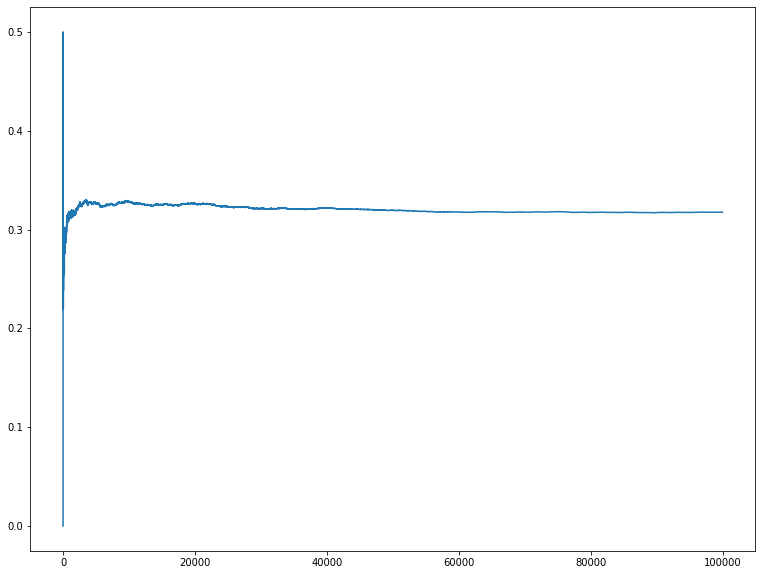

In [ ]:
# code for stability only. l and t are the same from the full simulation

# need to reference this 


import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

line_width = 20
needle_length = 10

def generate_needle_drop():
    d = np.random.uniform(0, line_width/2)
    theta = np.random.uniform(0,np.pi/2)
    
    if d < needle_length/2*np.sin(theta):
        return True
    else:
        return False
    
np.random.seed(0)

num_samples=100000

observations = np.zeros(num_samples)

for i in range(num_samples):
    observations[i] = generate_needle_drop()
    
mean_estimate = [np.average(observations[0:i]) for i in range(num_samples)]

plt.figure(figsize=(13,10))
plt.plot(np.arange(num_samples)+1, mean_estimate)

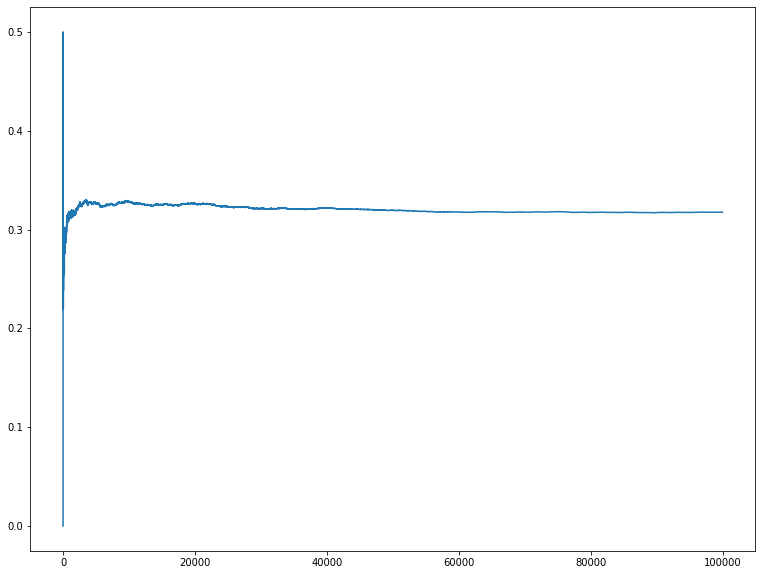

In [ ]:
# code for stability only

line_width = 3
needle_length = 1.5

def generate_needle_drop():
    d = np.random.uniform(0, line_width/2)
    theta = np.random.uniform(0,np.pi/2)
    
    if d < needle_length/2*np.sin(theta):
        return True
    else:
        return False
    
np.random.seed(0)

num_samples=100000

observations = np.zeros(num_samples)

for i in range(num_samples):
    observations[i] = generate_needle_drop()
    
mean_estimate = [np.average(observations[0:i]) for i in range(num_samples)]

plt.figure(figsize=(13,10))
plt.plot(np.arange(num_samples)+1, mean_estimate)

In [ ]:
mean_estimate

[nan,
 0.0,
 0.0,
 0.3333333333333333,
 0.5,
 0.4,
 0.3333333333333333,
 0.2857142857142857,
 0.25,
 0.3333333333333333,
 0.3,
 0.2727272727272727,
 0.3333333333333333,
 0.38461538461538464,
 0.42857142857142855,
 0.4,
 0.4375,
 0.4117647058823529,
 0.4444444444444444,
 0.42105263157894735,
 0.4,
 0.38095238095238093,
 0.36363636363636365,
 0.34782608695652173,
 0.3333333333333333,
 0.32,
 0.3076923076923077,
 0.2962962962962963,
 0.2857142857142857,
 0.27586206896551724,
 0.26666666666666666,
 0.25806451612903225,
 0.25,
 0.2727272727272727,
 0.2647058823529412,
 0.2571428571428571,
 0.25,
 0.24324324324324326,
 0.23684210526315788,
 0.23076923076923078,
 0.225,
 0.21951219512195122,
 0.23809523809523808,
 0.23255813953488372,
 0.22727272727272727,
 0.2222222222222222,
 0.2391304347826087,
 0.2553191489361702,
 0.25,
 0.24489795918367346,
 0.24,
 0.23529411764705882,
 0.23076923076923078,
 0.24528301886792453,
 0.24074074074074073,
 0.2545454545454545,
 0.26785714285714285,
 0.2631578

For our values for l and t 20 and 10 respectivly, when evaluating the stability of the randomness we spot that for the first 30 pi estimations our values are far from a desired probability (0.3) for 1000 needles. When increasing the number of needles, 

In [ ]:
# whem most stable, result agrees with initial prediction for propability 0.53snd

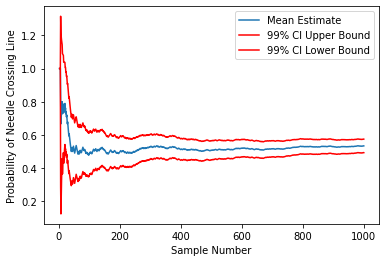

In [ ]:
# full code

line_width = 3.0
needle_length = 2.5

def generate_needle_drop():
    d = np.random.uniform(0, line_width/2)
    theta = np.random.uniform(0,np.pi/2)
    
    if d < needle_length/2*np.sin(theta):
        return True
    else:
        return False
    
np.random.seed(0)

num_samples=1000

observations = np.zeros(num_samples)

for i in range(num_samples):
    observations[i] = generate_needle_drop()
    
mean_estimate = [np.average(observations[0:i]) for i in range(num_samples)]

significance = 0.01
z_crit = stats.norm.ppf(1-significance/2)
confidence_int = [z_crit*stats.sem(observations[0:i]) for i in range(num_samples)]

plt.figure()
plt.plot(np.arange(num_samples)+1, mean_estimate, label='Mean Estimate')
plt.plot(np.arange(num_samples)+1, np.add(mean_estimate, confidence_int), 'r', label='99% CI Upper Bound')
plt.plot(np.arange(num_samples)+1, np.subtract(mean_estimate, confidence_int), 'r', label='99% CI Lower Bound')
plt.xlabel('Sample Number')
plt.ylabel('Probability of Needle Crossing Line')
plt.legend(loc='best')

In [ ]:
import numpy as np
import time

line_width = 3.0
needle_length = 2.5

def generate_needle_drop():
    d = np.random.uniform(0, line_width/2)
    theta = np.random.uniform(0, np.pi/2)
    
    if d < needle_length/2 * np.sin(theta):
        return True
    else:
        return False

np.random.seed(0)

num_samples = 100000  # Increased for a larger sample size

observations = np.zeros(num_samples)

# Record start time
start_time = time.time()

for i in range(num_samples):
    observations[i] = generate_needle_drop()

# Record end time
end_time = time.time()

# Estimate pi
probability = np.sum(observations) / num_samples
pi_estimate = (2 * needle_length) / (probability * line_width)

# Print results
print(f'Estimated value of pi: {pi_estimate:.9f}')
print(f'Probability of needle landing on a line: {probability:.4f}')
print(f'Time taken: {end_time - start_time:.6f} seconds')


Estimated value of pi: 3.140447074
Probability of needle landing on a line: 0.5307
Time taken: 0.719689 seconds


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

line_width = 3.0
needle_length = 2.5
num_samples = 450000000

def generate_needle_drop():
    d = np.random.uniform(0, line_width/2)
    theta = np.random.uniform(0, np.pi/2)
    
    if d < needle_length/2 * np.sin(theta):
        return True
    else:
        return False

np.random.seed(0)

# Record start time
start_time = time.time()

# Initialize counters
intersecting = 0


# Buffon's Needle simulation with grid lines
for _ in range(num_samples):
    x = np.random.uniform(0, line_width)
    y = np.random.uniform(0, line_width)
    

    # Visualization of needle drops
    if generate_needle_drop():
        intersecting += 1

# Record end time
end_time = time.time()

# Estimate pi
probability = intersecting / num_samples
pi_estimate = (2 * needle_length) / (probability * line_width)

# Print results
print(f'Estimated value of pi: {pi_estimate:.9f}')
print(f'Probability of needle landing on a line: {probability:.4f}')
print(f'Time taken: {end_time - start_time:.6f} seconds')


## Physical simulation of the Experiment

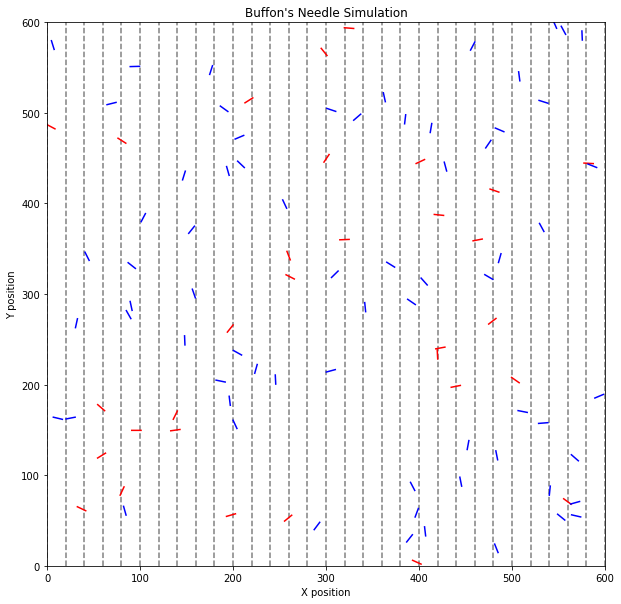

Probability: 0.31
Num needles: 100
Estimated value of pi: 3.225806452
Time taken: 0.301829 seconds


In [3]:
import numpy as np
import time

# Buffon's Needle simulation parameters
num_needles = 100 # Increased for a larger sample size
t = 20  # Adjusted for grid spacing
len_needle = 10  # Adjusted to be smaller than the spacing

# Record start time
start_time = time.time()

# Generate random angles and positions
angles = np.random.uniform(0, np.pi, num_needles)
positions = np.random.uniform(0, 600, num_needles)

# Calculate x-coordinates of both ends of the needles
x1 = positions - (len_needle / 2) * np.cos(angles)
x2 = positions + (len_needle / 2) * np.cos(angles)

# Check for intersections
line1 = np.floor(x1 / t)
line2 = np.floor(x2 / t)
intersections = np.sum(line1 != line2)

# Estimate pi
probability = intersections / num_needles
pi_estimate = (2 * len_needle) / (probability * t) if probability > 0 else float('inf')

import matplotlib.pyplot as plt

# Create a plot
plt.figure(figsize=(10, 10))

# Plot grid lines
for i in range(0, 601, t):
    plt.axvline(x=i, color='grey', linestyle='--')

# Plot needles
for x, angle, line1, line2 in zip(positions, angles, line1, line2):
    x_end1 = x - (len_needle / 2) * np.cos(angle)
    x_end2 = x + (len_needle / 2) * np.cos(angle)
    y_end1 = (len_needle / 2) * np.sin(angle)
    y_end2 = -y_end1

    # Adjust y-coordinates based on angle and midpoint position
    midpoint_y = np.random.uniform(0, 600)  # Random y position for the midpoint of the needle
    y_end1 += midpoint_y
    y_end2 += midpoint_y

    # Determine color based on intersection
    color = 'r' if line1 != line2 else 'b'

    plt.plot([x_end1, x_end2], [y_end1, y_end2], color=color)

# Set plot limits and labels
plt.xlim(0, 600)
plt.ylim(0, 600)
plt.xlabel('X position')
plt.ylabel('Y position')
plt.title('Buffon\'s Needle Simulation')
plt.savefig('visulised_board.png')

# Show the plot
plt.show()



# Record end time
end_time = time.time()


# Print the estimated value of pi and the time taken
print('Probability:', probability)
print('Num needles:', num_needles)
print(f'Estimated value of pi: {pi_estimate:.9f}')
print(f'Time taken: {end_time - start_time:.6f} seconds')